In [1]:
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from two_level_mc import * # adjust if your notebook is nested differently
from functions_v2 import *

In [3]:
import networkx as nx
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt

In [5]:
edges, n_vertices, edge_weights = load_graph("../../data/raw/power-US-Grid.mtx")

✓ Loaded: ../../data/raw/power-US-Grid.mtx
  Vertices : 4941
  Edges    : 6594
  Weighted : no



In [7]:
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 4941 x 4941
  Degree range: [1, 19]
  Non-zeros in L: 18129



In [9]:
lambda_min = compute_lambda_min(L, D)
L_sigma    = build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25)

✓ lambda_min = 0.000271
  (eigenvalues found: [0.         0.00027102])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse



In [11]:
# set seed for reproducibility
np.random.seed(42)

# run phase 3
u, B, cho_cache = run_phase3(L_sigma, lambda_min, edges, n_vertices)

✓ Phase 3 complete: correlated field u generated
  u range: [-3.7041, 1.7106]



In [13]:
G_nx = nx.Graph()
G_nx.add_edges_from(edges)

In [15]:
gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)

In [ ]:
G_nx_power = nx.Graph()
G_nx_power.add_nodes_from(range(n_vertices))
G_nx_power.add_edges_from(edges)
print(f"NetworkX graph built: {G_nx_power.number_of_nodes()} nodes, {G_nx_power.number_of_edges()} edges")

In [ ]:
pos = nx.spring_layout(G_nx, seed=42, k=0.3, iterations=50)
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("none")
ax.set_facecolor("none")
ax.axis("off")

gamma_out_set = set(gamma_out)
outlet_edges = [(i, j) for i, j in edges if i in gamma_out_set or j in gamma_out_set]

# draw all edges faint, then outlet edges bright/thick on top
nx.draw_networkx_edges(G_nx, pos, ax=ax, edgelist=edges, edge_color="white", width=0.4, alpha=0.15)
nx.draw_networkx_edges(G_nx, pos, ax=ax, edgelist=outlet_edges, edge_color="#4ce0c1", width=2.2, alpha=0.9)

nc = nx.draw_networkx_nodes(G_nx, pos, ax=ax, nodelist=list(range(n_vertices)),
                              node_size=[60 + G_nx.degree(v)*15 for v in range(n_vertices)],
                              node_color=[p[v] for v in range(n_vertices)],
                              cmap=plt.cm.coolwarm, vmin=0, vmax=1, alpha=0.95)
cb = plt.colorbar(nc, ax=ax, shrink=0.6)
cb.set_label("p value", color="white")
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")

ax.set_title("Pressure Field — highlighted edges contribute to Q", color="white", fontsize=14)

plt.tight_layout()
plt.savefig("powergrid_p_and_Q.png", dpi=200, bbox_inches="tight", transparent=True)
plt.close()

In [ ]:
k = compute_permeability(u, edges)

In [ ]:
# weighted laplacian 
L_k = build_weighted_laplacian(edges, n_vertices, k)

In [ ]:
p  = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)

In [21]:
Q_samples= monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                          gamma_in, gamma_out, edge_weights=None,
                          N=1000, use_amg=False, debug=True)

Monte Carlo: 100%|██████████| 1000/1000 [00:47<00:00, 20.88sample/s, mean Q=20.4603]


✓ Done — 1000 samples
  Mean Q : 20.460274
  Std Q  : 377.708596



=== Monte Carlo Results ===
  Samples : 1000
  Mean Q  : 20.460274
  Std Q   : 377.708596
  Var Q   : 142663.783458
  Min Q   : 0.000006
  Max Q   : 9725.669586
Saved as uspowergrid_phase7.png


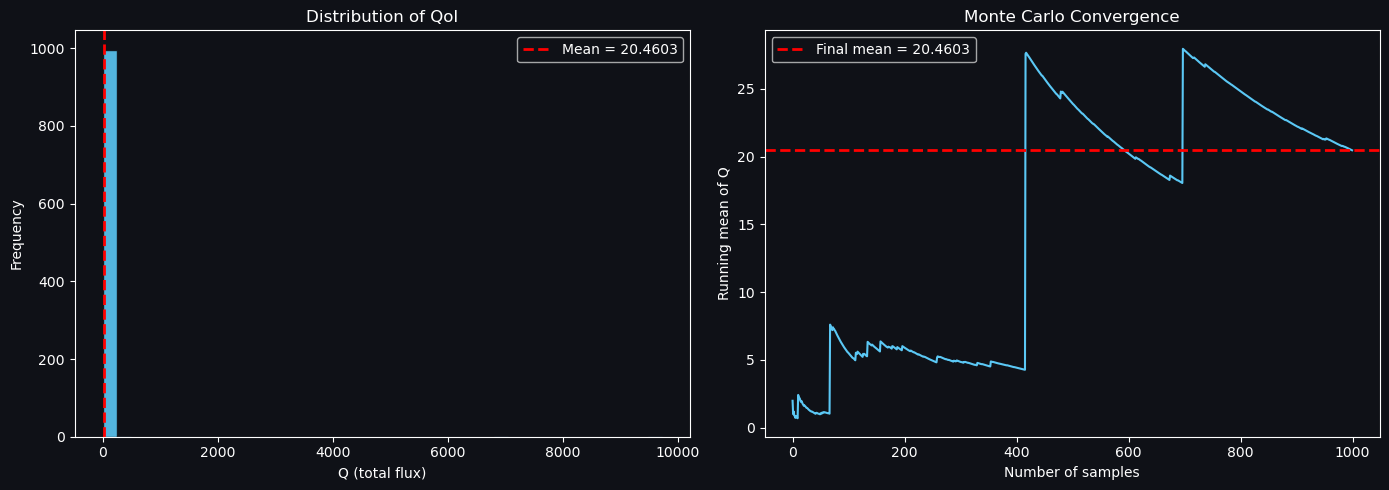

In [23]:
analyze_qoi(Q_samples, save_as="uspowergrid_phase7.png" )

In [25]:
Q_samples= monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                          gamma_in, gamma_out, edge_weights=None,
                          N=2000, use_amg=False, debug=True)

Monte Carlo: 100%|██████████| 2000/2000 [01:48<00:00, 18.44sample/s, mean Q=6.4439]


✓ Done — 2000 samples
  Mean Q : 6.443920
  Std Q  : 47.152673



=== Monte Carlo Results ===
  Samples : 2000
  Mean Q  : 6.443920
  Std Q   : 47.152673
  Var Q   : 2223.374538
  Min Q   : 0.000002
  Max Q   : 1430.192033


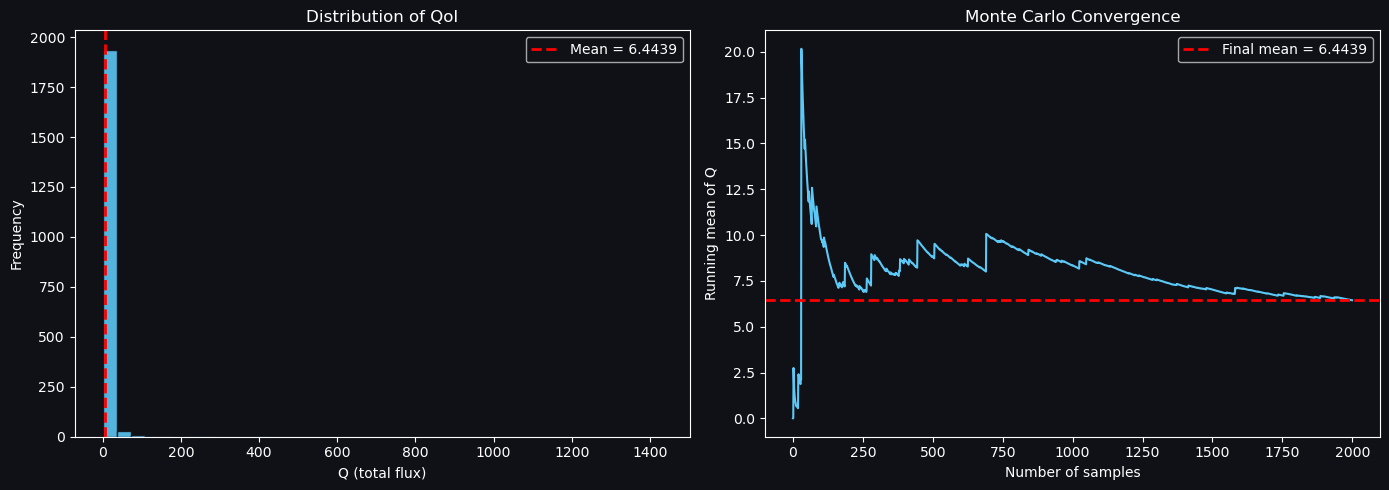

In [27]:
analyze_qoi(Q_samples, save_as=None)

In [30]:
Q_samples

array([4.14515742e-03, 5.41685270e-02, 8.18134134e+00, ...,
       4.33405297e+00, 4.39414567e-03, 2.54782683e-01])

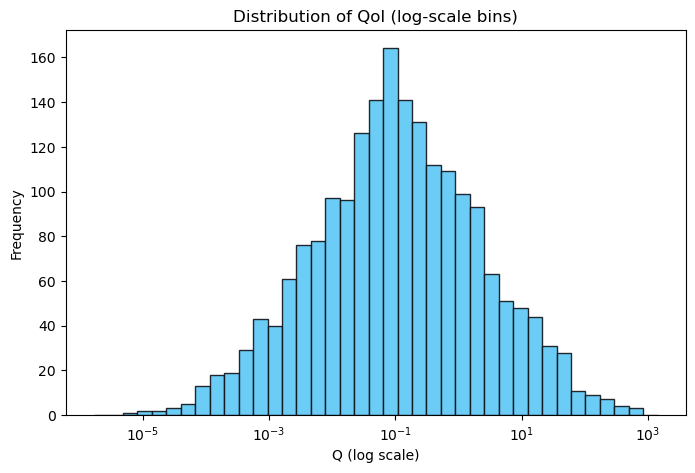

In [32]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(Q_samples, bins=np.logspace(np.log10(Q_samples.min()+1e-10), np.log10(Q_samples.max()), 40),
        color="#5bc8f5", edgecolor="#0f1117", alpha=0.9)
ax.set_xscale('log')
ax.set_xlabel("Q (log scale)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of QoI (log-scale bins)")
plt.show()